In [22]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [23]:
# READ DATASET
df = pd.read_csv("customer_data.csv")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (200, 5)
   age  annual_income  spending_score  savings  purchase_frequency
0   56          78053               5    26677                   6
1   69          41959              68    44081                  21
2   46          25530               6    32569                   2
3   32          23748              96    28322                  13
4   60          33545              94    24065                  11


In [24]:
# SCALING
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)


In [25]:
# K-MEANS 
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

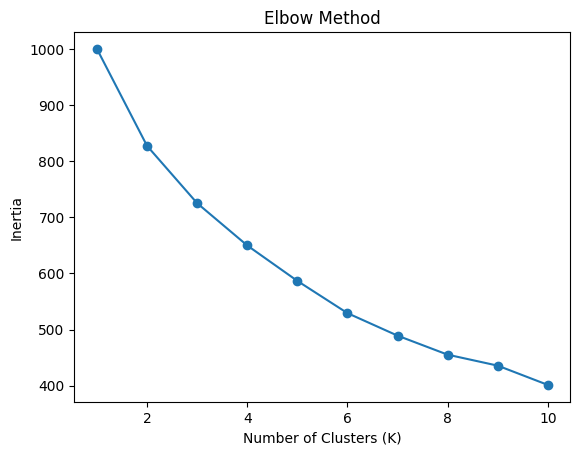

In [26]:
# ELBOW METHOD
plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

In [27]:
#  SILHOUETTE SCORE
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"K={k}, Silhouette Score={score}")

K=2, Silhouette Score=0.16615193915640597
K=3, Silhouette Score=0.1581268798068598
K=4, Silhouette Score=0.15762198818440884
K=5, Silhouette Score=0.17006696962610593
K=6, Silhouette Score=0.18004448724928054
K=7, Silhouette Score=0.17385298665530555
K=8, Silhouette Score=0.18290745026927113
K=9, Silhouette Score=0.17635215830546058
K=10, Silhouette Score=0.18615134696896832


In [28]:
optimal_k = 3

#  FINAL CLUSTERING
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print("\nCluster Assigned:")
print(df.head())


Cluster Assigned:
   age  annual_income  spending_score  savings  purchase_frequency  Cluster
0   56          78053               5    26677                   6        1
1   69          41959              68    44081                  21        0
2   46          25530               6    32569                   2        0
3   32          23748              96    28322                  13        0
4   60          33545              94    24065                  11        0


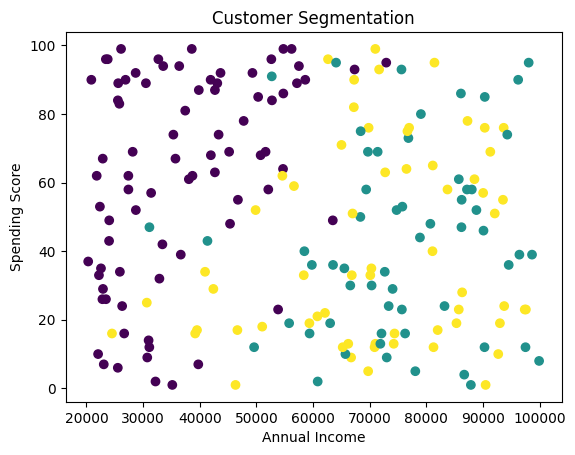

In [29]:
#  VISUALIZATION
plt.figure()

plt.scatter(df["annual_income"], df["spending_score"], c=df["Cluster"])

plt.title("Customer Segmentation")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.show()